## **DESops Tutorial 01**

`DESops` is a Python library for studying discrete event systems. The library implements many useful algorithms and provides a convenient, uniform interface for manipulating automata models. The intent is to facilitate prototyping and testing of new methods, hence an emphasis on usability and visualization.

This tutorial will cover the basics of the `DESops` library: creating automata, file IO, visualization, basic operations on automata, and an introduction to supervisory control methods. 

Part 02 of the tutorial covers further supervisory control methods, language equivalence, random automata, efficient unobservable reach, and applications in sensor deception attacks and opacity.

In [1]:
import DESops as d

## **Outline**
* [Automata Class](#Automata-Class)
* [Creating From Scratch](#Creating-an-Automaton-From-Scratch)
* [Reading and Writing Files](#Reading-and-Writing-Files)
* [Visualization](#Visualization)
* [Compositions](#Compositions)
* [Supervisory Control](#Supervisory-Control)

___

### **Automata Class**
There are different objects for `DFA`, `NFA` and `PFA`s. All inherit the same base class and use roughly the same interface.

`DFA` by default ensures the determinism invariance and will raise an error if it's violated (can be disabled, see `add_edge(s)` for DFA).

`PFA` includes probabilistic information on transitions.

`NFA` allows multiple initial states to be set. 

`print` the automaton for a summary in the form of an adjacency list, or use the method `summary(use_state_names=False)`, which allows printing state indices instead of names if *use_state_names* is set to *False*.

In [6]:
# Create an empty deterministic finite automaton.
g = d.DFA()

# equivalent to print(g.summary(use_state_names=True))
print(g) 

# Or nondeterministic FA and probablistic FA objects:
g_NFA = d.NFA()
g_PFA = d.PFA()

DFA : 0 V, 0 E
Source | (Target, Event), ...)



In addition to transitions and states, automata are often defined with partitions on the set of events. The sets `Euc` and `Euo` are used to stored events which are, respectively, uncontrollable and unobservable. The set of events are stored in `events`, which is maintained automatically as transitions are added.
These sets are preserved through compositions and are used generally in supervisory control functions.

For an automata defined with an event set $\Sigma$ (represented by the `events` member variable), the controllable and observable event sets can be inferred as $\Sigma_c=\Sigma \backslash \Sigma_{uc}$ and $\Sigma_o=E \backslash \Sigma_{uo}$.

___

### **Creating an Automaton From Scratch**
The methods `add_vertex`, `add_vertices`, `add_edge` and `add_edges` are used in the following way:
* `add_vertex([name], [marked], **kwargs)`
    * `name`: optionally provide vertex name. If not provided, the vertex index will be used as a string.
    * `marked`: optionally provide marked state information (True/False; default False).
    * optionally provide additional keyword arguments.


* `add_vertices(num_vertices, [names], [marked], **kwargs)`
Where `num_vertices` is an integer, and lists of keyword arguments can be optionally provided.

* `add_edge(source, target, label, fill_out=True, **kwargs)`
    * `source` and `target` are integers referring to vertex indices.
    * `label` is the intended label of the transition as an Event object (or converted into an Event object).


* `add_edges(pair_list, labels, fill_out=True, **kwargs)`
    * `pair_list` is a list of tuples, i.e. `[(source, target), ...]` where source and target are integers referring to vertex indices.
    * `labels` is a list of labels as Event objects. (All non-Event object labels are converted into Event objects.)


In [7]:
g.add_vertex(name=None, marked=True)
g.add_vertices(2, names=["1", "2"])
print(g)

DFA : 3 V, 0 E
Source | (Target, Event), ...)
0*:  []
1 :  []
2 :  []



When printing the summary, marked state names are followed by an asterisk (\*).

Although no name was supplied for vertex 0, it took the name "0" (i.e. *str(0)*)

Finally, note that although states '2' and '3' did not have markings specified, they are unmarked.

In [8]:
g.add_edges([(0, 1), (1,2), (2,2)], ["a", 14, d.Event("c")])
print(g)

DFA : 3 V, 3 E
Source | (Target, Event), ...)
0*:  [('1', 'a')]
1 :  [('2', 14)]
2 :  [('2', c)]

{'a', c, 14}


#### DFA determinism check

For a DFA, an additional parameter checks that adding these transitions won't violate determinism:
* `DFA.edd_edge(source, target, label, check_DFA=True, ...)`
* `DFA.add_edges(pair_list, labels, check_DFA=True, ...)`

A `DeterminismError` will be raised if `check_DFA=True` and there's a violation. The default value of `check_DFA` is `True`.

In [9]:
# Can't have two transitions leaving state 0 with label "a":
try:
    g.add_edge(0, 1, "a")
except d.error.DeterminismError:
    pass
# g still only has three total transitions:
print(g)

DFA : 3 V, 3 E
Source | (Target, Event), ...)
0*:  [('1', 'a')]
1 :  [('2', 14)]
2 :  [('2', c)]



#### Performance Note with adding edges
When adding many edges, it is recommended to *use as few* `add_edges` calls as possible, as this is much faster than
repeated `add_edge` calls or `add_edges` with smaller sets of edges. 

(This is due to igraph maintaining an adjacency matrix, which gets updated when edges are added. See their documentation for more details.)

### Automata Representation
The automata objects use an igraph directed Graph to store the transition system. igraph Graphs use `VertexSeq` and `EdgeSeq` objects to represent vertices and edges, respectively.

These can be accessed using the `vs()` and `es()` methods:

In [10]:
print(g.vs())
print(g.es())

igraph also maintains keyword attributes for vertices and edges, which we use to store names of vertices in `vs["name"]`, labels for transitions in `es["label"]`, and state markings for marked systems in `vs["marked"]`.

These keyword attributes are accessed in the `VertexSeq` and `EdgeSeq` objects as dictionary keys.


In [11]:
print(g.vs["name"][1])
print(g.es["label"][1])
print(g.vs["marked"])

1
14
[True, False, False]


#### Outgoing Adjacency List
While igraph has methods to access an adjacency list, it is sometimes much faster to use the `DESops` maintained `"out"` keyword attribute attached to the `VertexSeq`.

`vs["out"][v]` for some vertex *v* is a list in the form `[(t, label), ...]` where transitions are defined *E(v, label) = t*

In [12]:
print(g.vs["out"])

# View the out-list for vertex index 1
v1_out = g.vs["out"][1]

# The tuples are implemented as `namedtuple("target", "label")`, and so they can be accessed by either index or keyword.
print("Out(target=2, label=14) : ", v1_out[0].target, v1_out[0].label)

[[Out(target=1, label='a')], [Out(target=2, label=14)], [Out(target=2, label=c)]]
Out(target=2, label=14) :  2 14


When using `add_edge(s)`, the `"out"` attribute is updated as long as the parameter `fill_out=True` (default behavior).

`"out"` can be regenerated using the `generate_out()` method.


#### Event Class
The `VertexSeq` and `EdgeSeq` attributes are useful for storing additional information to be attached to each vertex or edge. A downside to this method is that attributes as key-value pairs must map to every vertex/edge. In other words, it can't be used to set an attribute for any particular vertex or edge.

In most cases, having a sparse list is an acceptable workaround.

A workaround included in `DESops` is to use the `Event` object to store labels/events on edges. Generally, labels/events in DESops are stored as `Event` objects. For most usage, the `Event` object is abstracted away, and events can be manipulated using any hashable datatype, which are then converted to `Event` objects internally (must be hashable since events are stored in sets). 

The `Event` class-structure gives additional flexibility: a key-value pair can be included in the `Event` class, and so it's a dict-mapping only defined for that particular edge, rather than every edge in the case of `EdgeSeq` attributes.


For example, we can have an event with a label "a" and custom attribute "controllable" which takes a boolean value:

In [13]:
e_c = d.Event("a", controllable=True)
e_uc = d.Event("a")

def is_controllable(e):
    if "controllable" in e.__dict__:
        return e.controllable
    return False
print("e_c controllable: ", is_controllable(e_c))
print("e_uc controllable: ", is_controllable(e_uc))

e_c controllable:  True
e_uc controllable:  False


The helper function `is_controllable` is needed in this example because the *controllable* attribute has not been defined for *e_uc*. Accessing as `e_uc.controllable` would raise an `AttributeError`.

In most situations, setting an `EdgeSeq` attribute would result in cleaner code than using an `Event` attribute.

___

### **Reading and Writing Files**

`DESops` uses the `.fsm` fileformat (used by DESUMA software) to read/write automata.

The methods are `read_fsm(filename)` and `write_fsm(filename, automaton)`

In [14]:
d.write_fsm("g.fsm", g)
g_2 = d.read_fsm("g.fsm")
print(g_2)

DFA : 3 V, 3 E
Source | (Target, Event), ...)
0*:  [('1', a)]
1 :  [('2', 14)]
2 :  [('2', c)]



There are also methods for reading/writing to other file formats, including the `pickle` format.

* `write_pickle(filename, automaton)`
* `read_pickle(filename, automaton)`

___

### **Visualization**
Automata can be visualized using `pycairo` plots or the `svg` file format.

Using the `plot()` function requires the optional package `pycairo`. Plotting is done using the `igraph` plot function. See the `igraph` `plot()` [documentation](https://igraph.org/python/doc/igraph.drawing-module.html)
for more details on their implementation.

The `svg` format is a flexible way to store visualizations. They can be viewed in standard web browsers, and edited using a software tool like inkscape.
The `write_svg()` function is a reimplementation of the `igraph` function of the same name, with some minor changes. Due to inkscape using an older version of the `svg` fileformat,
use the parameter `to_inkscape=True` to have an `svg` editable by inkscape, or `to_inkscape=False` to open in a browser window.

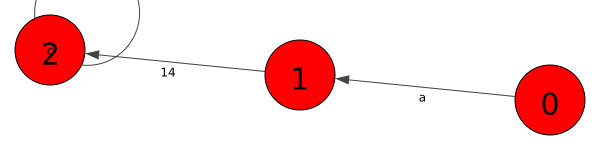

In [15]:
# Cramped view in a Jupyter notebook, but plots are in general are inflexible compared to svg.
# However, plots can be readily displayed inline or saved directly to common image file formats:
d.plot(g, bbox=(0,0, 600, 150), margin=50, inline=True)

In [16]:
d.write_svg("g.svg", g, to_inkscape=False)

In [17]:
# This may not work in all notebook viewers. Try opening the .svg file in browser to see result.
# Or, rerun the previous block with to_inkscape=True and open in inkscape to edit the plot.
from IPython.core.display import SVG
SVG(filename='g.svg')

---

### **Compositions**

DESops implements the the parallel, product and observer compositions.
The functions are in the `composition` submodule within DESops, along with several other useful operators.

* `product(**input_list)` computes the completely synchronous composition $G_1 \times ... \times G_n$ where `input_list=(G1, ..., Gn)`.
* `parallel(**input_list)` computes the synchronous composition $G_1 || ... || G_n$ where `input_list=(G1, ..., Gn)`.

* `observer(input)` computes the observer automaton $Obs(G)$ for `input=G`.


#### Ex: Product and parallel composition
For binary operators, vertex names become a tuple with each item being the name of an associated vertex in the input.

This example uses two automata from "Introduction to Discrete Event Systems" (2008), in figures 2.1 and 2.2.

In [18]:
g1 = d.read_fsm("tests/models/textbook/fig_2-1.fsm")
g2 = d.read_fsm("tests/models/textbook/fig_2-2.fsm")
print("g1: ", g1)
print("g2: ", g2)

g1:  DFA : 3 V, 7 E
Source | (Target, Event), ...)
x*:  [('x', a), ('z', g)]
y :  [('x', a), ('y', b)]
z*:  [('y', a), ('z', b), ('y', g)]

g2:  DFA : 2 V, 4 E
Source | (Target, Event), ...)
0 :  [('1', a), ('0', b)]
1*:  [('1', a), ('0', b)]



In [19]:
g1_prod_g2 = d.composition.product(g1, g2)
print("g1 X g2: ", g1_prod_g2)

g1 X g2:  DFA : 2 V, 2 E
Source | (Target, Event), ...)
('x', '0') :  [(('x', '1'), a)]
('x', '1')*:  [(('x', '1'), a)]



In [20]:
g1_par_g2 = d.composition.parallel(g1, g2)
print("g1 || g2: ", g1_par_g2)

g1 || g2:  DFA : 6 V, 14 E
Source | (Target, Event), ...)
('x', '0') :  [(('z', '0'), g), (('x', '1'), a)]
('z', '0') :  [(('y', '0'), g), (('z', '0'), b), (('y', '1'), a)]
('x', '1')*:  [(('z', '1'), g), (('x', '1'), a)]
('y', '0') :  [(('y', '0'), b), (('x', '1'), a)]
('y', '1') :  [(('y', '0'), b), (('x', '1'), a)]
('z', '1')*:  [(('y', '1'), g), (('z', '0'), b), (('y', '1'), a)]



We can also string together multiple inputs in a single composition:

In [21]:
# Note that this is equivalent to d.composition.parallel(g1, g1_par_g2) up to names of states:
g1_par_g1_par_g2 = d.composition.parallel(g1, g1, g2)
print(g1_par_g1_par_g2)

DFA : 6 V, 14 E
Source | (Target, Event), ...)
(('x', 'x'), '0') :  [((('z', 'z'), '0'), g), ((('x', 'x'), '1'), a)]
(('z', 'z'), '0') :  [((('y', 'y'), '0'), g), ((('z', 'z'), '0'), b), ((('y', 'y'), '1'), a)]
(('x', 'x'), '1')*:  [((('z', 'z'), '1'), g), ((('x', 'x'), '1'), a)]
(('y', 'y'), '0') :  [((('y', 'y'), '0'), b), ((('x', 'x'), '1'), a)]
(('y', 'y'), '1') :  [((('y', 'y'), '0'), b), ((('x', 'x'), '1'), a)]
(('z', 'z'), '1')*:  [((('y', 'y'), '1'), g), ((('z', 'z'), '0'), b), ((('y', 'y'), '1'), a)]



#### Ex: Observer computation for partially observed automata

The observer of a partially observed (deterministic finite) automaton is a deterministic automaton whose states are state estimates of the input automata, and whose language is equivalent to the projection of the input language ($\mathcal{L}(Obs(G)) = P[\mathcal{L}(G)]$)


In [22]:
g_po = d.read_fsm("tests/models/G_t.fsm")
print("Unobserverable: ", g_po.Euo)
print(g_po)

Unobserverable:  {w, u, v}
DFA : 7 V, 9 E
Source | (Target, Event), ...)
1 :  [('2', b), ('3', a)]
2 :  [('5', v)]
3 :  [('5', u), ('4', w)]
4 :  [('7', b)]
5 :  [('6', b)]
6*:  [('6', c)]
7*:  [('7', c)]



In [23]:
g_obs = d.composition.observer(g_po)
print(g_obs)

DFA : 5 V, 6 E
Source | (Target, Event), ...)
frozenset({'1'}) :  [(frozenset({'2', '5'}), b), (frozenset({'3', '5', '4'}), a)]
frozenset({'2', '5'}) :  [(frozenset({'6'}), b)]
frozenset({'3', '5', '4'}) :  [(frozenset({'7', '6'}), b)]
frozenset({'6'})*:  [(frozenset({'6'}), c)]
frozenset({'7', '6'})*:  [(frozenset({'7', '6'}), c)]



Several notes on the observer computation:
* States in g_obs are sets of states of g_po.
* There are no transitions defined for the unobservable events {u, v, w}.
* Only states *{6}* and *{6, 7}* in the observer are marked since they contain at least one marked state in g_po.


Computing the observer caches information in g_po, resulting in a faster observer computation, and the extra memory can be released with
    `G.UR.empty()`. See part two of the tutorial for more details on the unobservable reach and the UR class.
    

In [ ]:
print("Before emptying cache: ", g_po.UR)
g_po.UR.empty()
print("After empyting cache: ", g_po.UR)


___

### Supervisory Control

In this last section, we introduce functions in `DESops` for solving supervisory control problems.

The `supervisor.supremal_sublanguage` submodule computes the supremal sublanguage of a given plant and specification.

`supervisor.supremal_sublanguage(plant, spec, [Euc, Euo, mode, preprocess, prefix_closed, num_cores])`

* `plant` should be a `DFA`.

* `spec` can be either a `DFA` (automata/langauge based specification) or a `set()` of names of unsafe states in `plant` (state based specification).

* The `mode` argument specifies an enumerable type to compute either the controllable, normal or controllable & normal sublanguage. It's possible values are `d.supervisor.Mode.[CONTROLLABLE, NORMAL, CONTROLLABLE_NORMAL]`. Default is `CONTROLLABLE_NORMAL`.



* `preprocess` is a boolean argument which constructs $\tilde{G}$ and $\tilde{H}$ from $G$ and $H$, such that preprocessing requirements are met.

* Finally, if `prefix_closed=True`, the prefix-closed sublanguage will be computed. Otherwise, the marked language will be computed.

When `spec` is given as an automaton, a requirement is that the specification is a subautomaton of the plant. The preprocessing requirement is not explicitly checked, but by default `preprocess` is True. The preprocessing steps are as follows:

0. If `spec` is a `set()` (state based specification): find $H$ by removing states in `spec` from $G$

1. If `mode` is `CONTROLLABLE_NORMAL` or `NORMAL`: compute $G$ from $G_{input}$ such that $G$ is a state partitioned automata (SPA), i.e. $G=G_{input} || Obs(G_{input})$

2. Construct From $G$ and $H$ $\tilde{H}$ is a subautomaton of $\tilde{G}$ (for state based specifications, the subautomata requirement is already met)

3. If `prefix_closed=True`: mark states in $H$ if their associated state in $G$ are marked


In [2]:
# Load plant G and specification H from .fsm files:
G = d.read_fsm("tests/models/sc_tests/book_ex_3_11_G.fsm")
H = d.read_fsm("tests/models/sc_tests/book_ex_3_11_H.fsm")
print("Uncontrollable events:", G.Euc)

Uncontrollable events: {a1, b1}


Here, the `plant` $G$ and `spec` $H$ are both modeled as `DFA` objects.

In [3]:
# Compute the supremal controllable supervisor:
S = d.supervisor.supremal_sublanguage(G, H, mode=d.supervisor.Mode.CONTROLLABLE, preprocess=True, prefix_closed=False)
print(S)

DFA : 0 V, 0 E
Events: set()
Euc: set()
Euo: set()
Source | (Target, Event), ...)



In this example, the computed supervisor is the empty automaton. Therefore, a controllable sublanguage does not exist.


---

Here is another example with only partial observation: there are unobservable events in addition to uncontrollable ones.

The supervisor computed here generates the (marked) supremal controllable normal language.

In [4]:
G_po = d.read_fsm("tests/models/scn_tests/cn_test1_g.fsm")
H_po = d.read_fsm("tests/models/scn_tests/cn_test1_h.fsm")

# supervisor methods use the union of plant and spec Euc,Euo sets:
print("Uncontrollable: ", G_po.Euc.union(H_po.Euc))
print("Unobservable: ", G_po.Euo.union(H_po.Euc))

print("Marked states G: ", [v["name"] for v in G_po.vs if v["marked"]])
print("Marked states H: ", [v["name"] for v in H_po.vs if v["marked"]])

Uncontrollable:  set()
Unobservable:  {u, v, w}
Marked states G:  ['6', '7']
Marked states H:  ['6']


In [5]:
S_scn = d.supervisor.supremal_sublanguage(G_po, H_po, mode=d.supervisor.Mode.CONTROLLABLE_NORMAL, prefix_closed=False)
print(S_scn)

DFA : 4 V, 4 E
Events: {b, a, c, v, w, u}
Euc: set()
Euo: {u, v, w}
Source | (Target, Event), ...)
0 :  [('1', b)]
1 :  [('3', v)]
3 :  [('6', b)]
6*:  [('6', c)]



Since this system is fully controllable, the controllable normal sublanguage is also the normal sublanguage:

In [6]:
# Change the supervisor.Mode enum type to NORMAL
S_scn = d.supervisor.supremal_sublanguage(G_po, H_po, mode=d.supervisor.Mode.NORMAL, prefix_closed=False)
print(S_scn)

DFA : 4 V, 4 E
Events: {b, a, c, v, w, u}
Euc: set()
Euo: {u, v, w}
Source | (Target, Event), ...)
0 :  [('1', b)]
1 :  [('3', v)]
3 :  [('6', b)]
6*:  [('6', c)]



Part 2 of the tutorial includes alternative methods for solving supervisory control problems in `DESops`.